In [1]:
pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd

# Load dataset
df = pd.read_excel(r"C:\Users\acer\OneDrive\Documents\superstore_cleaned.xlsx")

# Show first 5 rows
df.head()

,order_id,order_date,Year,ship_date,ship_mode,customer_name,segment,state,country,market,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01 00:00:00,2011.0,2011-06-01 00:00:00,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01 00:00:00,2011.0,2011-08-01 00:00:00,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01 00:00:00,2011.0,2011-05-01 00:00:00,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01 00:00:00,2011.0,2011-05-01 00:00:00,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01 00:00:00,2011.0,2011-08-01 00:00:00,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [19]:
df = df.drop(columns=['Year'])

In [20]:
# Convert to datetime (safety)
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['order_date'])

# Create daily demand
daily_demand = df.groupby('order_date')['quantity'].sum().reset_index()

# Rename columns
daily_demand.columns = ['Date', 'Demand']

# Sort by date
daily_demand = daily_demand.sort_values(by='Date')

# View result
daily_demand.head()

,Date,Demand
0,2011-01-01,19
1,2011-01-02,54
2,2011-01-03,177
3,2011-01-04,86
4,2011-01-06,154


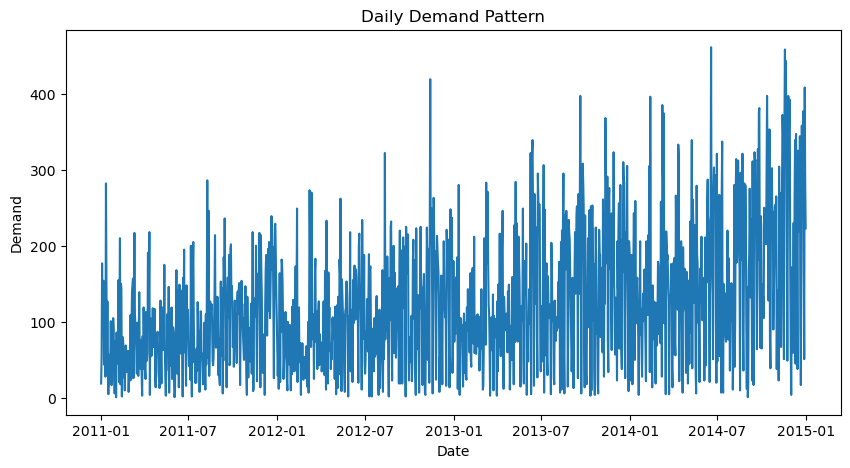

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily_demand['Date'], daily_demand['Demand'])
plt.title("Daily Demand Pattern")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.show()

In [22]:
import numpy as np

# Convert demand column to list
demand_series = daily_demand['Demand'].values

# Function to simulate demand
def get_demand(day):
    base_demand = demand_series[day % len(demand_series)]
    
    # Add randomness (noise)
    noise = np.random.normal(0, 5)  # mean=0, std=5
    
    simulated_demand = max(0, base_demand + noise)
    
    return int(simulated_demand)

In [23]:
for i in range(10):
    print(get_demand(i))

22
56
172
82
161
55
104
95
28
283


In [24]:
inventory = 500
pending_orders = []

selling_price = 100
cost_price = 60
holding_cost = 1
stockout_penalty = 20

In [25]:
def simulate_day(day, inventory, pending_orders, order_quantity):
    
    # 1. Demand
    demand = get_demand(day)
    
    # 2. Sales
    sales = min(inventory, demand)
    
    # 3. Stockout
    lost_sales = max(0, demand - inventory)
    
    # 4. Update inventory
    inventory -= sales
    
    # 5. Receive orders (if any arrive today)
    arrivals = [o for o in pending_orders if o['arrival_day'] == day]
    
    for order in arrivals:
        inventory += order['quantity']
    
    # Remove delivered orders
    pending_orders = [o for o in pending_orders if o['arrival_day'] > day]
    
    # 6. Place new order
    if order_quantity > 0:
        lead_time = np.random.randint(2, 6)
        pending_orders.append({
            'quantity': order_quantity,
            'arrival_day': day + lead_time
        })
    
    # 7. Profit calculation
    revenue = sales * selling_price
    cost = order_quantity * cost_price
    holding = inventory * holding_cost
    penalty = lost_sales * stockout_penalty
    
    profit = revenue - cost - holding - penalty
    
    return inventory, pending_orders, profit, demand, sales, lost_sales

In [26]:
inventory = 500
pending_orders = []

profits = []

for day in range(30):
    order_quantity = 50  # fixed for now
    
    inventory, pending_orders, profit, demand, sales, lost_sales = simulate_day(
        day, inventory, pending_orders, order_quantity
    )
    
    profits.append(profit)

print("Simulation complete")

Simulation complete


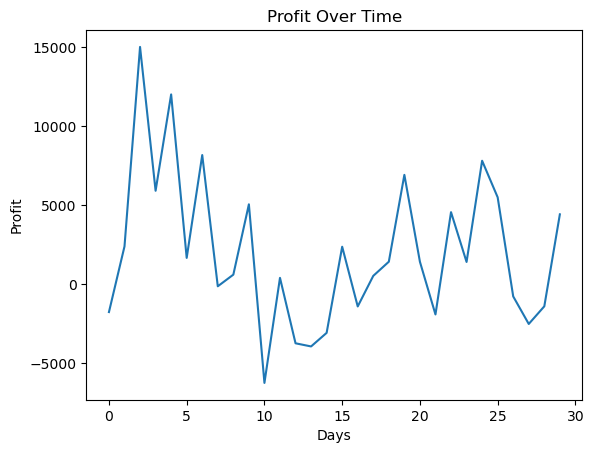

In [27]:
import matplotlib.pyplot as plt

plt.plot(profits)
plt.title("Profit Over Time")
plt.xlabel("Days")
plt.ylabel("Profit")
plt.show()

In [28]:
actions = [0, 20, 50, 100]

In [29]:
Q = {}

In [30]:
def get_q(state, action):
    return Q.get((state, action), 0)

In [31]:
import random

episodes = 500

alpha = 0.1   # learning rate
gamma = 0.9   # discount
epsilon = 0.2 # exploration

for ep in range(episodes):
    
    inventory = 500
    pending_orders = []
    
    for day in range(30):
        
        state = int(inventory // 50)  # reduce state size
        
        # Choose action (explore vs exploit)
        if random.random() < epsilon:
            action = random.choice(actions)
        else:
            q_values = [get_q(state, a) for a in actions]
            action = actions[q_values.index(max(q_values))]
        
        # Simulate
        inventory, pending_orders, reward, _, _, _ = simulate_day(
            day, inventory, pending_orders, action
        )
        
        next_state = int(inventory // 50)
        
        # Q update
        old_q = get_q(state, action)
        next_max = max([get_q(next_state, a) for a in actions])
        
        new_q = old_q + alpha * (reward + gamma * next_max - old_q)
        
        Q[(state, action)] = new_q

In [32]:
inventory = 500
pending_orders = []

profits = []

for day in range(30):
    
    state = int(inventory // 50)
    
    q_values = [get_q(state, a) for a in actions]
    action = actions[q_values.index(max(q_values))]
    
    inventory, pending_orders, profit, demand, sales, lost = simulate_day(
        day, inventory, pending_orders, action
    )
    
    profits.append(profit)

print("AI simulation done")

AI simulation done


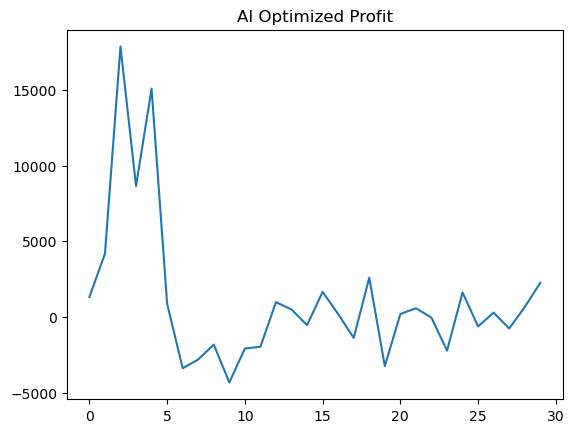

In [33]:
plt.plot(profits)
plt.title("AI Optimized Profit")
plt.show()

In [34]:
records = []

inventory = 500
pending_orders = []

for day in range(100):
    
    state = int(inventory // 50)
    
    q_values = [get_q(state, a) for a in actions]
    action = actions[q_values.index(max(q_values))]
    
    inventory, pending_orders, profit, demand, sales, lost = simulate_day(
        day, inventory, pending_orders, action
    )
    
    records.append({
        "Day": day,
        "Inventory": inventory,
        "Demand": demand,
        "Sales": sales,
        "Lost Sales": lost,
        "Order Quantity": action,
        "Profit": profit
    })

In [35]:
result_df = pd.DataFrame(records)
result_df.head()

,Day,Inventory,Demand,Sales,Lost Sales,Order Quantity,Profit
0,0,485,15,15,0,0,1015
1,1,437,48,48,0,20,3163
2,2,260,177,177,0,0,17440
3,3,179,81,81,0,0,7921
4,4,28,151,151,0,0,15072


In [40]:
result_df.to_csv("C:\\Users\\acer\\OneDrive\\Documents\\simulation_output.csv", index=False)